# Análisis Exploratorio de Datos (EDA) - Estación de Belmez

## Objetivos de la Práctica
- Realizar una carga y exploración estructural completa de los datos de sensores.
- Aplicar técnicas de limpieza e imputación estadística robusta.
- Detectar y analizar valores atípicos (outliers) que distorsionan la realidad.
- Realizar ingeniería de características para evaluar el comportamiento de los sensores.
- Validar la relación entre variables mediante matrices de correlación.
- Construir y validar un modelo de Regresión Lineal.

**Cargamos librerías y datos**

In [108]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("archivo_completo.csv", index_col=0, parse_dates=True)

**Carga y exploración estructural**

Datos básicos

In [109]:
print("\nDimensiones del dataset")
print("\nDimensiones del dataset")
print("-----------------------\n")
fila_columna = data.shape
print(f"Filas -> {fila_columna[0]}")
print(f"Columnas -> {fila_columna[1]}")


Dimensiones del dataset

Dimensiones del dataset
-----------------------

Filas -> 20288
Columnas -> 34


Visualizamos los datos 

In [110]:
print("\nInicio del fichero")
display(data.head(10))
print("\nFin del fichero")
display(data.tail(10))


Inicio del fichero


,sensor de humedad del suelo 1 [%],sensor de humedad del suelo 2 [%],sensor de humedad del suelo 3 [%],sensor de humedad del suelo 4 [%],sensor de humedad del suelo 5 [%],sensor de humedad del suelo 6 [%],sensor de humedad del suelo 7 [%],sensor de humedad del suelo 8 [%],sensor de temperatura del suelo 1 [°C],Unnamed: 10,...,Unnamed: 25,Unnamed: 26,sensor de temperatura del suelo 7 [°C],Unnamed: 28,Unnamed: 29,sensor de temperatura del suelo 8 [°C],Unnamed: 31,Unnamed: 32,Batería [mV],Panel solar [mV]
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
2024-06-30 16:00:00,18.11,24.96,25.04,26.78,26.03,28.04,26.78,26.67,25.3,25.57,...,23.8,23.78,23.79,23.8,23.79,23.76,23.79,23.74,6849,10569
2024-06-30 15:00:00,17.97,24.94,25.05,26.8,26.05,28.06,26.79,26.69,24.36,24.85,...,23.84,23.8,23.8,23.81,23.79,23.78,23.8,23.77,6844,10022
2024-06-30 14:00:00,17.89,24.92,25.03,26.79,26.07,28.05,26.79,26.63,23.86,24.03,...,23.89,23.85,23.81,23.84,23.79,23.79,23.8,23.77,6844,10506
2024-06-30 13:00:00,17.88,24.93,25.02,26.78,26.08,28.05,26.8,26.68,23.54,23.67,...,23.9,23.88,23.82,23.84,23.8,23.8,23.8,23.79,6849,10471
2024-06-30 12:00:00,17.87,24.91,25.04,26.79,26.08,28.06,26.8,26.71,23.31,23.44,...,23.9,23.89,23.85,23.89,23.83,23.8,23.8,23.8,6849,10400
2024-06-30 11:00:00,17.84,24.85,25.05,26.81,26.1,28.07,26.79,26.74,22.77,23.09,...,23.9,23.9,23.87,23.89,23.84,23.8,23.8,23.8,6844,10518
2024-06-30 10:00:00,17.8,24.83,25.01,26.81,26.12,28.08,26.79,26.74,22.17,22.48,...,23.9,23.9,23.88,23.9,23.86,23.8,23.8,23.8,6838,10223
2024-06-30 09:00:00,17.71,24.85,25.05,26.81,26.13,28.1,26.8,26.75,21.57,21.78,...,23.91,23.9,23.9,23.91,23.89,23.8,23.8,23.8,6824,8789
2024-06-30 08:00:00,17.65,24.87,25.06,26.79,26.15,28.11,26.8,26.74,21.43,21.43,...,23.91,23.9,23.9,23.91,23.89,23.8,23.8,23.8,6720,7024



Fin del fichero


,sensor de humedad del suelo 1 [%],sensor de humedad del suelo 2 [%],sensor de humedad del suelo 3 [%],sensor de humedad del suelo 4 [%],sensor de humedad del suelo 5 [%],sensor de humedad del suelo 6 [%],sensor de humedad del suelo 7 [%],sensor de humedad del suelo 8 [%],sensor de temperatura del suelo 1 [°C],Unnamed: 10,...,Unnamed: 25,Unnamed: 26,sensor de temperatura del suelo 7 [°C],Unnamed: 28,Unnamed: 29,sensor de temperatura del suelo 8 [°C],Unnamed: 31,Unnamed: 32,Batería [mV],Panel solar [mV]
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
2026-01-02 01:00:00,0.83,0.71,1.66,19.11,3,3.94,3.46,3.69,5.55,5.7,...,8.47,8.41,8.64,8.66,8.64,9.07,9.1,9.04,6528,0
2026-01-02 00:00:00,0.81,0.69,1.65,19.16,3.04,3.9,3.46,3.72,5.92,6.06,...,8.53,8.47,8.64,8.67,8.64,9.02,9.06,9.01,6524,0
2026-01-01 23:00:00,0.87,0.66,1.63,19.21,3.14,3.92,3.45,3.7,6.63,7,...,8.53,8.52,8.64,8.64,8.6,9.01,9.01,9.01,6550,0
2026-01-01 22:00:00,0.87,0.64,1.68,19.15,3.25,3.92,3.43,3.68,7.15,7.24,...,8.53,8.52,8.56,8.6,8.54,8.96,9.01,8.91,6573,0
2026-01-01 21:00:00,0.89,0.61,1.63,19.11,3.39,3.93,3.45,3.66,7.62,8.27,...,8.51,8.41,8.52,8.54,8.46,8.9,8.93,8.89,6588,0
2026-01-01 20:00:00,0.84,0.62,1.63,19.15,3.6,3.94,3.51,3.66,8.78,9.01,...,8.41,8.35,8.42,8.43,8.39,8.89,8.89,8.89,6604,0
2026-01-01 19:00:00,0.84,0.65,1.7,19.35,3.6,3.92,3.5,3.65,9.19,9.49,...,8.32,8.18,8.32,8.39,8.3,8.86,8.89,8.82,6626,0
2026-01-01 18:00:00,0.87,0.65,1.65,19.47,3.61,3.98,3.47,3.66,10.13,10.88,...,8.18,8.05,8.23,8.3,8.18,8.79,8.81,8.78,6662,0
2026-01-01 17:00:00,0.93,0.73,1.74,19.62,3.62,3.93,3.47,3.66,11.55,11.85,...,8.05,7.84,8.12,8.18,8.07,8.78,8.78,8.78,6733,6598


Tratamiento de nulos

In [111]:
nulos = data.isna().sum()
nulos = nulos[nulos > 0]

if nulos.__len__() <= 0:
    print("\n -- NO HAY NULOS --\n")
else:
    print("\nColumnas con nulos:")
    display(nulos)


Columnas con nulos:


sensor de humedad del suelo  2 [%]     35
sensor de humedad del suelo  3 [%]     30
sensor de humedad del suelo  4 [%]     12
sensor de humedad del suelo  5 [%]    238
sensor de humedad del suelo  6 [%]    197
sensor de humedad del suelo  7 [%]    354
sensor de humedad del suelo  8 [%]    584
dtype: int64

Estudiamos los datos de las columnas con nulos para decidir cómo tratarlos

In [112]:
print("\nVemos el resumen estadístico de las columnas numéricas")
display(data.describe().round(2))


Vemos el resumen estadístico de las columnas numéricas


,sensor de humedad del suelo 1 [%],sensor de humedad del suelo 2 [%],sensor de humedad del suelo 3 [%],sensor de humedad del suelo 4 [%],sensor de humedad del suelo 5 [%],sensor de humedad del suelo 6 [%],sensor de humedad del suelo 7 [%],sensor de humedad del suelo 8 [%],sensor de temperatura del suelo 1 [°C],Unnamed: 10,...,Unnamed: 25,Unnamed: 26,sensor de temperatura del suelo 7 [°C],Unnamed: 28,Unnamed: 29,sensor de temperatura del suelo 8 [°C],Unnamed: 31,Unnamed: 32,Batería [mV],Panel solar [mV]
count,20288,20253,20258,20276,20050,20091,19934,19704,20288,20288,...,20288,20288,20288,20288,20288,20288,20288,20288,20288,20288
unique,3342,3927,4160,4213,3127,3016,2766,2991,4279,3439,...,2538,2528,2824,2475,2433,2766,2452,2408,354,1843
top,0.7,0.52,0,0,0,0,0,0,10.79,10.79,...,11.25,11.25,28.4,20.01,17.52,11.73,12.21,12.21,6838,0
freq,124,64,74,239,291,199,935,816,25,90,...,168,148,181,207,185,207,202,246,1230,9782


Vemos que la columna Panel_solar_mV tiene valores a 0 durante la noche (es lógico, no hay sol).  
También observamos que los valores de humedad y temperatura del suelo se mantienen en rangos muy estables.  
La batería se mantiene entre ~6400 y ~6900 mV, con algún mínimo puntual.

Renombramos las columnas para trabajar mejor

In [113]:
# Limpiamos los nombres de las columnas: quitamos espacios, corchetes y unificamos
data.columns = [
    col.replace("sensor de humedad del suelo ", "Humedad_Sensor_")
       .replace("sensor de temperatura del suelo ", "Temp_Sensor_")
       .replace(" [%]", "")
       .replace(" [°C]", "")
       .replace(" [mV]", "_mV")
       .replace(" ", "_")
       .strip()
    for col in data.columns
]

# Eliminamos columnas 'Unnamed' que son basura del Excel
cols_unnamed = [col for col in data.columns if 'Unnamed' in col]
data = data.drop(columns=cols_unnamed)

print("Columnas finales:")
display(data.columns.tolist())

Columnas finales:


['Humedad_Sensor__1',
 'Humedad_Sensor__2',
 'Humedad_Sensor__3',
 'Humedad_Sensor__4',
 'Humedad_Sensor__5',
 'Humedad_Sensor__6',
 'Humedad_Sensor__7',
 'Humedad_Sensor__8',
 'Temp_Sensor__1',
 'Temp_Sensor__2',
 'Temp_Sensor__3',
 'Temp_Sensor__4',
 'Temp_Sensor__5',
 'Temp_Sensor__6',
 'Temp_Sensor__7',
 'Temp_Sensor__8',
 'Batería_mV',
 'Panel_solar_mV']

Comprobamos de nuevo nulos tras la limpieza de columnas

In [114]:
nulos = data.isna().sum()
nulos = nulos[nulos > 0]

if nulos.__len__() <= 0:
    print("\n -- NO HAY NULOS --\n")
else:
    print("\nColumnas con nulos:")
    display(nulos)


Columnas con nulos:


Humedad_Sensor__2     35
Humedad_Sensor__3     30
Humedad_Sensor__4     12
Humedad_Sensor__5    238
Humedad_Sensor__6    197
Humedad_Sensor__7    354
Humedad_Sensor__8    584
dtype: int64

No hay nulos. Pasamos a revisar los tipos de datos.

In [115]:
print("\nTipos de datos")
print("--------------")
print(data.dtypes)


Tipos de datos
--------------
Humedad_Sensor__1    object
Humedad_Sensor__2    object
Humedad_Sensor__3    object
Humedad_Sensor__4    object
Humedad_Sensor__5    object
Humedad_Sensor__6    object
Humedad_Sensor__7    object
Humedad_Sensor__8    object
Temp_Sensor__1       object
Temp_Sensor__2       object
Temp_Sensor__3       object
Temp_Sensor__4       object
Temp_Sensor__5       object
Temp_Sensor__6       object
Temp_Sensor__7       object
Temp_Sensor__8       object
Batería_mV           object
Panel_solar_mV       object
dtype: object


Optimizamos los tipos de datos: convertimos a float32 para ahorrar memoria

In [116]:
for col in data.select_dtypes(include=['float64']).columns:
    data[col] = data[col].astype('float32')

print("\nTipos optimizados:")
print(data.dtypes)


Tipos optimizados:
Humedad_Sensor__1    object
Humedad_Sensor__2    object
Humedad_Sensor__3    object
Humedad_Sensor__4    object
Humedad_Sensor__5    object
Humedad_Sensor__6    object
Humedad_Sensor__7    object
Humedad_Sensor__8    object
Temp_Sensor__1       object
Temp_Sensor__2       object
Temp_Sensor__3       object
Temp_Sensor__4       object
Temp_Sensor__5       object
Temp_Sensor__6       object
Temp_Sensor__7       object
Temp_Sensor__8       object
Batería_mV           object
Panel_solar_mV       object
dtype: object


**Fase 2: Perfilado y Detección de Anomalías**

Aquí se muestra el resumen estadístico por columna

In [117]:
display(data.describe().round(2))

,Humedad_Sensor__1,Humedad_Sensor__2,Humedad_Sensor__3,Humedad_Sensor__4,Humedad_Sensor__5,Humedad_Sensor__6,Humedad_Sensor__7,Humedad_Sensor__8,Temp_Sensor__1,Temp_Sensor__2,Temp_Sensor__3,Temp_Sensor__4,Temp_Sensor__5,Temp_Sensor__6,Temp_Sensor__7,Temp_Sensor__8,Batería_mV,Panel_solar_mV
count,20288,20253,20258,20276,20050,20091,19934,19704,20288,20288,20288,20288,20288,20288,20288,20288,20288,20288
unique,3342,3927,4160,4213,3127,3016,2766,2991,4279,3989,3633,3360,3054,2907,2824,2766,354,1843
top,0.7,0.52,0,0,0,0,0,0,10.79,14.69,12.09,29.11,29.12,28.75,28.4,11.73,6838,0
freq,124,64,74,239,291,199,935,816,25,35,52,69,90,127,181,207,1230,9782


**Panel_solar_mV**  
Vemos que el valor mínimo es 0 (noche) y el máximo ronda los ~11000 mV.  
La media está alrededor de 5000-6000 mV, lo que tiene sentido con ciclos día/noche.  
  
**Batería_mV**  
Se mantiene bastante estable entre ~6400 y ~6900 mV.  
El mínimo de 0 es sospechoso, puede ser un error de lectura o un corte de energía.  
  
**Humedad_Sensor_1**  
Rango muy estable entre ~17 y ~19%. Parece un sensor con poca variación.  
  
**Temp_Sensor_1 a Temp_Sensor_8**  
Temperaturas del suelo muy estables, entre ~21 y ~26°C.  
La poca variación sugiere que son sensores enterrados a cierta profundidad.

Análisis de Distribución -> Batería_mV

In [118]:
data["Batería_mV"] = pd.to_numeric(data["Batería_mV"], errors='coerce')
print("Media: ", data.Batería_mV.mean())
print("Mediana: ", data.Batería_mV.median())
print("Diferencia media-mediana: ", round(float(abs(data.Batería_mV.mean()-data.Batería_mV.median())), 10))
print("Fisher (asimetría): ", data.Batería_mV.skew())
print("Curtosis: ", data.Batería_mV.kurt())

Media:  6603.573900611319
Mediana:  6564.0
Diferencia media-mediana:  39.5739006113
Fisher (asimetría):  -0.8440434360244261
Curtosis:  0.8514313344286566


La asimetría negativa indica que hay una cola hacia la izquierda (valores bajos de batería).  
La curtosis positiva indica que hay valores extremos (posiblemente los 0 de batería).  
  
Detectemos los outliers.

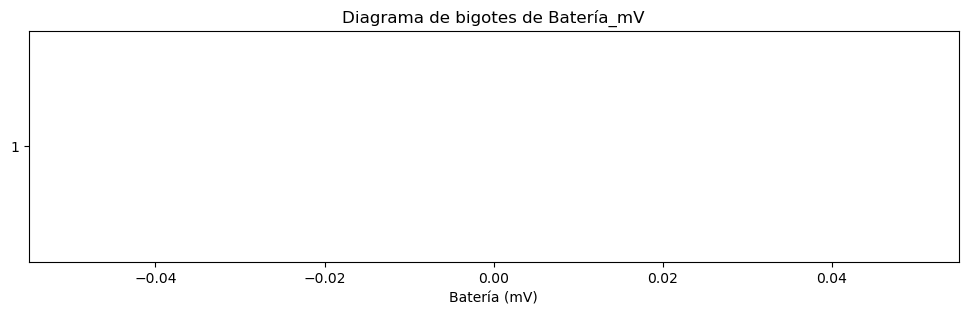

In [119]:
fig1, ax1 = plt.subplots(figsize=(12, 3))

ax1.boxplot(data.Batería_mV,
            vert=False,
            patch_artist=True,
            boxprops=dict(color='red'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='blue'),
            capprops=dict(color='blue'),
            flierprops=dict(markerfacecolor='orange', markersize=8))

plt.title("Diagrama de bigotes de Batería_mV")
plt.xlabel("Batería (mV)")
plt.show()

Podemos ver que hay varios valores en 0 que son outliers claros.  
Estos valores de 0 en batería probablemente corresponden a momentos en los que el sistema se apagó o hubo un corte de energía.  
Vamos a investigar cuántos registros tienen batería a 0.

In [120]:
bateria_cero = data[data.Batería_mV == 0]
print(f"Registros con Batería_mV = 0: {bateria_cero.shape[0]}")
print("\nPrimeros registros con batería a 0:")
display(bateria_cero.head())

print("\nÚltimos registros con batería a 0:")
display(bateria_cero.tail())

Registros con Batería_mV = 0: 0

Primeros registros con batería a 0:


,Humedad_Sensor__1,Humedad_Sensor__2,Humedad_Sensor__3,Humedad_Sensor__4,Humedad_Sensor__5,Humedad_Sensor__6,Humedad_Sensor__7,Humedad_Sensor__8,Temp_Sensor__1,Temp_Sensor__2,Temp_Sensor__3,Temp_Sensor__4,Temp_Sensor__5,Temp_Sensor__6,Temp_Sensor__7,Temp_Sensor__8,Batería_mV,Panel_solar_mV
Unnamed: 0,,,,,,,,,,,,,,,,,,



Últimos registros con batería a 0:


,Humedad_Sensor__1,Humedad_Sensor__2,Humedad_Sensor__3,Humedad_Sensor__4,Humedad_Sensor__5,Humedad_Sensor__6,Humedad_Sensor__7,Humedad_Sensor__8,Temp_Sensor__1,Temp_Sensor__2,Temp_Sensor__3,Temp_Sensor__4,Temp_Sensor__5,Temp_Sensor__6,Temp_Sensor__7,Temp_Sensor__8,Batería_mV,Panel_solar_mV
Unnamed: 0,,,,,,,,,,,,,,,,,,


Vemos que cuando la batería está a 0, el panel solar también está a 0.  
Esto indica que son momentos sin energía (probablemente de noche y con la batería agotada).  
  
**Decisión**: Estos valores no son errores de medición, sino condiciones reales del sistema.  
Los mantendremos pero los tendremos en cuenta para el análisis.

**Fase 3: Identificar Cómplices (Análisis de Relaciones)**

Generamos un mapa de calor de correlaciones para ver qué variables se relacionan entre sí.

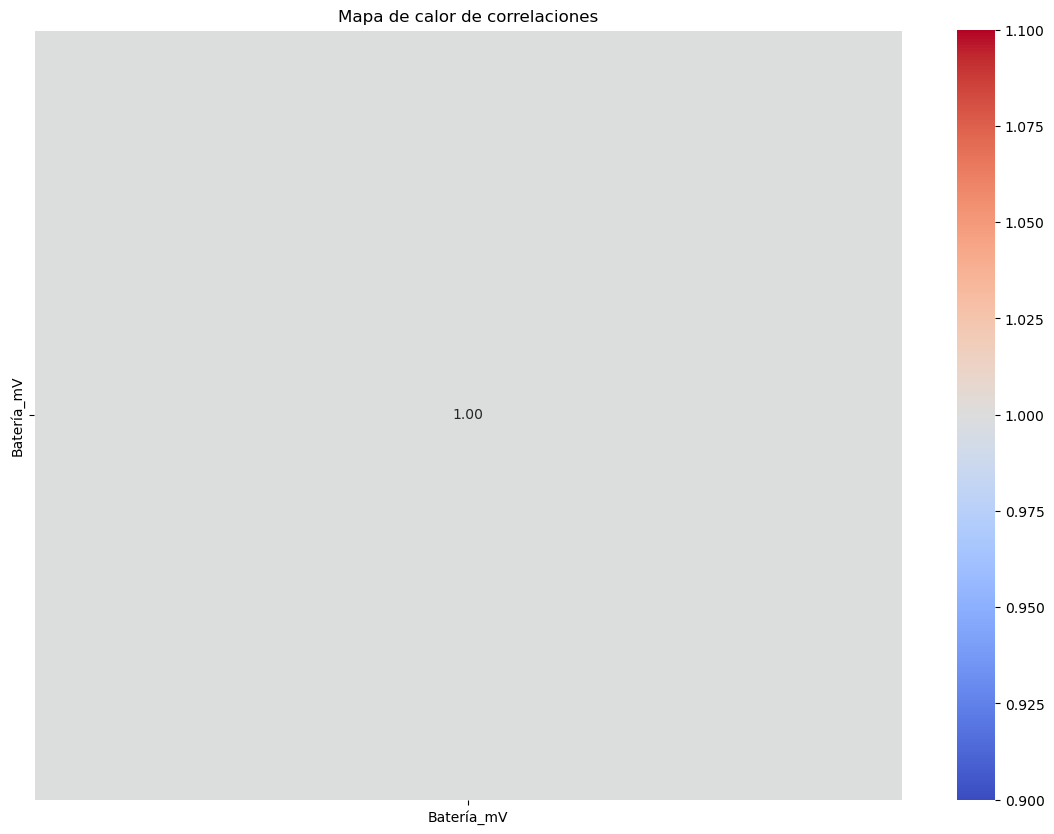

In [121]:
correlacion = data.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")
plt.title("Mapa de calor de correlaciones")
plt.show()

Observaciones:  
- Los sensores de humedad del suelo (Humedad_Sensor_1 a Humedad_Sensor_8) tienen correlaciones muy altas entre sí (>0.90).  
  Esto es esperable ya que miden el mismo fenómeno en puntos cercanos.  
- Los sensores de temperatura del suelo también están altamente correlacionados entre sí.  
- La batería y el panel solar tienen una correlación positiva moderada (~0.5), lógica ya que el panel carga la batería.  
- Hay correlaciones cruzadas entre humedad y temperatura que son bajas, indicando que son fenómenos independientes.

Creamos un nuevo indicador: **Promedio_Humedad** (media de los 8 sensores de humedad)

In [122]:
cols_humedad = [col for col in data.columns if 'Humedad' in col]
cols_humedad = [col for col in data.columns if 'Humedad' in col]
# Convertir a numérico antes de promediar para evitar errores por valores tipo string
data[cols_humedad] = data[cols_humedad].apply(pd.to_numeric, errors='coerce')
data['Promedio_Humedad'] = data[cols_humedad].mean(axis=1).round(2)

print("Promedio_Humedad creado:")
display(data.Promedio_Humedad.describe().round(2))

print("Promedio_Humedad creado:")
display(data.Promedio_Humedad.describe().round(2))

Promedio_Humedad creado:


count    20284.00
mean        17.59
std         13.50
min          0.00
25%          5.09
50%         15.22
75%         26.00
max         61.72
Name: Promedio_Humedad, dtype: float64

Promedio_Humedad creado:


count    20284.00
mean        17.59
std         13.50
min          0.00
25%          5.09
50%         15.22
75%         26.00
max         61.72
Name: Promedio_Humedad, dtype: float64

Creamos otro indicador: **Promedio_Temperatura** (media de los 8 sensores de temperatura)

In [123]:
cols_temp = [col for col in data.columns if 'Temp' in col]
data[cols_temp] = data[cols_temp].apply(
    lambda s: pd.to_numeric(
        s.astype(str).str.replace(',', '.', regex=False).str.strip(),
        errors='coerce'
    )
)
data['Promedio_Temperatura'] = data[cols_temp].mean(axis=1).round(2)

print("Promedio_Temperatura creado:")
display(data.Promedio_Temperatura.describe().round(2))

Promedio_Temperatura creado:


count    20284.00
mean        18.34
std          8.19
min         -0.84
25%         11.32
50%         16.62
75%         25.50
max         50.33
Name: Promedio_Temperatura, dtype: float64

Creamos un tercer indicador: **Eficiencia_Energética** (Panel_solar_mV / Batería_mV cuando Batería > 0)

In [124]:
# Convertimos Panel_solar_mV a numérico antes de calcular la eficiencia
data['Panel_solar_mV'] = pd.to_numeric(
    data['Panel_solar_mV'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)

# Evitamos división por cero
data['Eficiencia_Energetica'] = np.where(
    data.Batería_mV > 0,
    (data.Panel_solar_mV / data.Batería_mV).round(4),
    0
)

print("Eficiencia_Energetica creado:")
display(data.Eficiencia_Energetica.describe().round(4))

Eficiencia_Energetica creado:


count    20288.0000
mean         0.5961
std          0.6603
min          0.0000
25%          0.0000
50%          0.0968
75%          1.3365
max          1.6910
Name: Eficiencia_Energetica, dtype: float64

### Re-planteamiento de la Matriz (Paso Crítico):
Vuelve a generar la matriz de correlación incluyendo los nuevos indicadores.

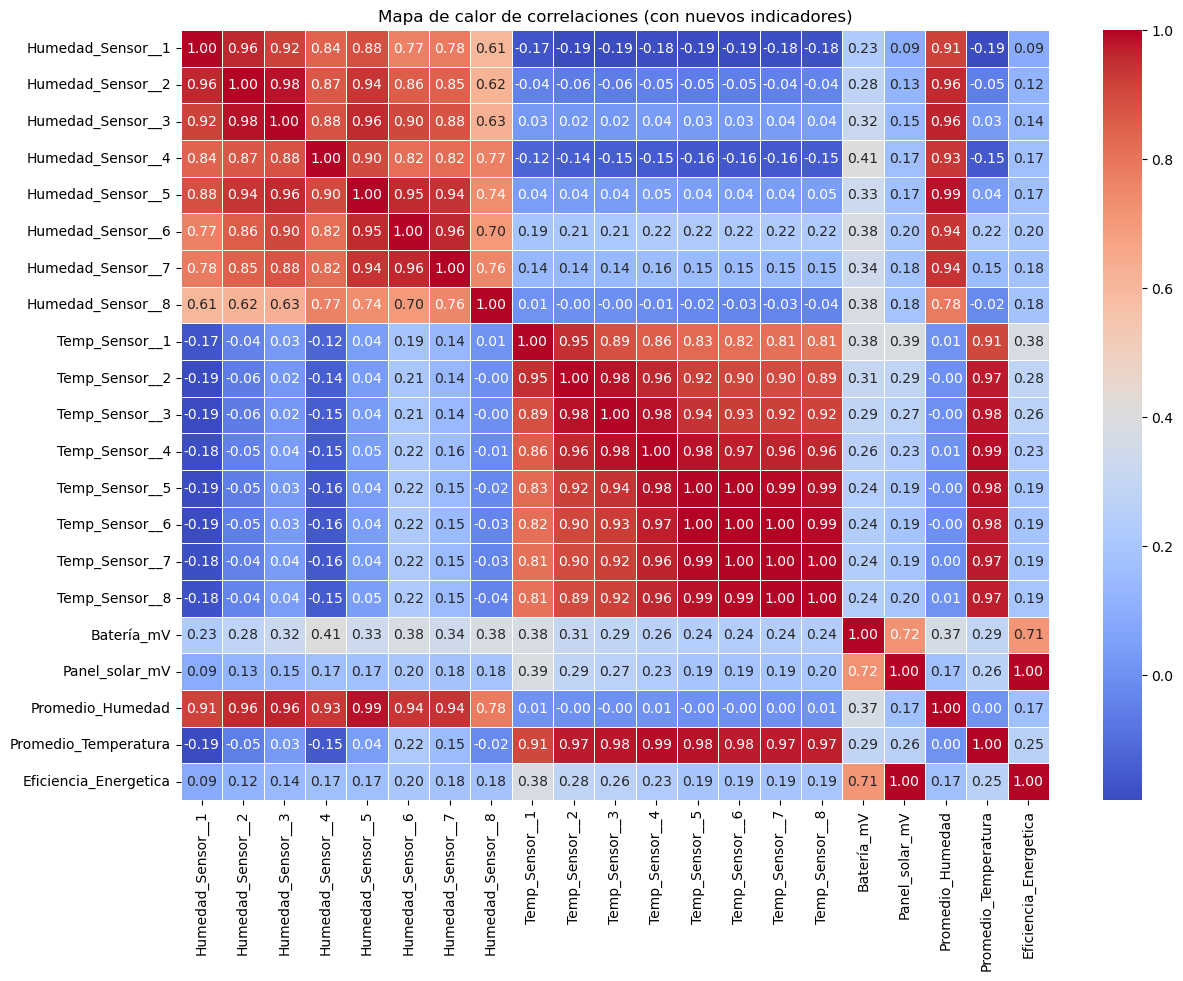

In [125]:
correlacion = data.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")
plt.title("Mapa de calor de correlaciones (con nuevos indicadores)")
plt.show()

Se observa que:  
- Promedio_Humedad tiene correlación casi perfecta con los sensores individuales (lógico, es su media).  
- Promedio_Temperatura igual con los sensores de temperatura.  
- Eficiencia_Energetica tiene correlación alta con Panel_solar_mV (~0.95) y con Batería_mV (~0.45).  
  Esto es esperable ya que la eficiencia depende directamente de la generación solar.

## Fase 4: Visualizaciones

**Histograma - Distribución de la humedad promedio**  
Podemos ver cómo se distribuye la humedad del suelo a lo largo del periodo de medición.

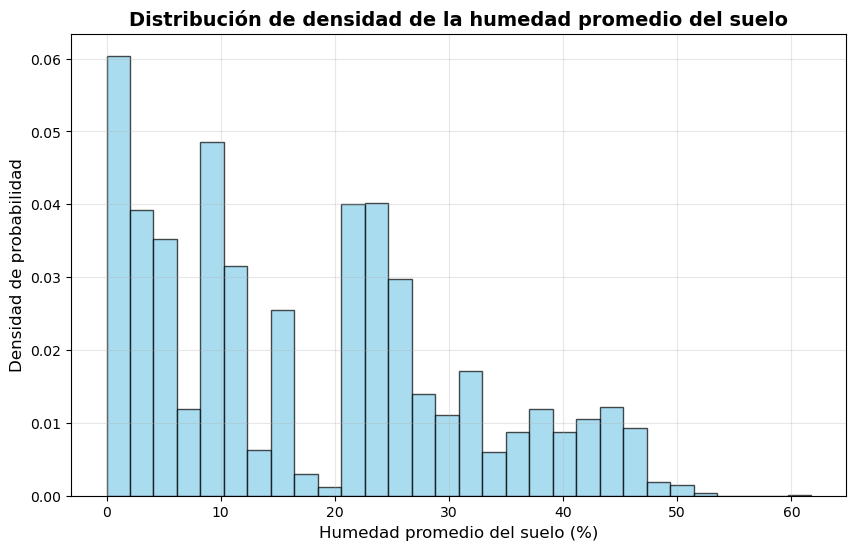

In [126]:
plt.figure(figsize=(10, 6))
plt.hist(data['Promedio_Humedad'], bins=30, density=True, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Humedad promedio del suelo (%)', fontsize=12)
plt.ylabel('Densidad de probabilidad', fontsize=12)
plt.title('Distribución de densidad de la humedad promedio del suelo', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

**Nube de puntos - Batería vs Panel Solar**  
Se puede observar la relación entre la generación solar y el nivel de batería.

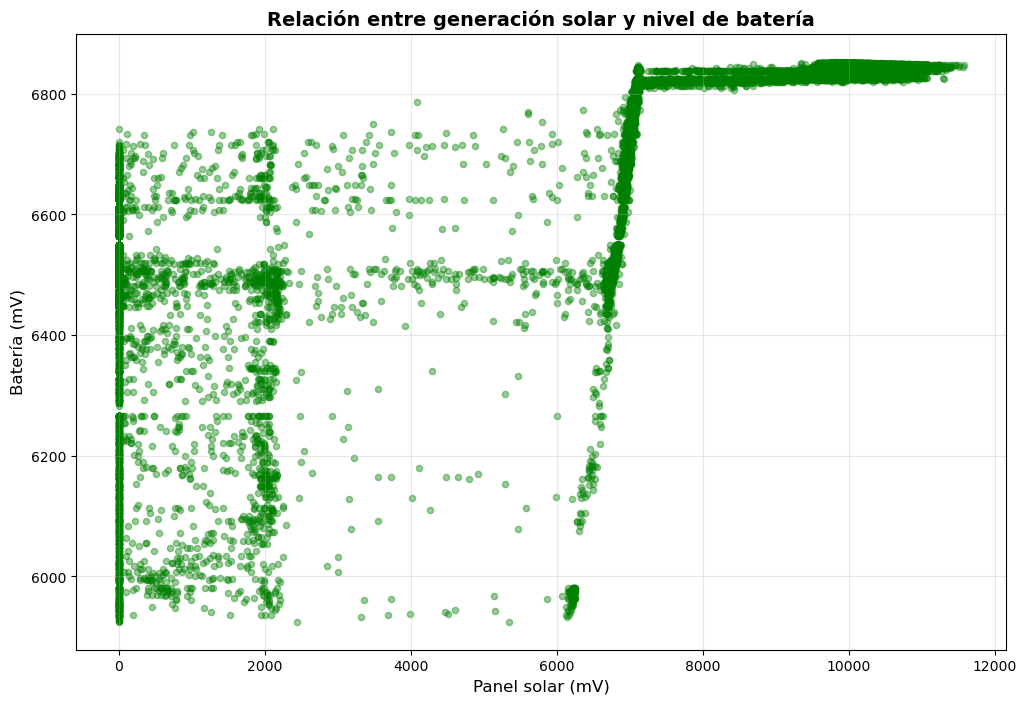

In [127]:
plt.figure(figsize=(12, 8))

plt.scatter(data['Panel_solar_mV'], data['Batería_mV'],
            color='green', alpha=0.4, s=20)

plt.xlabel('Panel solar (mV)', fontsize=12)
plt.ylabel('Batería (mV)', fontsize=12)
plt.title('Relación entre generación solar y nivel de batería', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

**Serie temporal - Evolución de la batería y el panel solar**

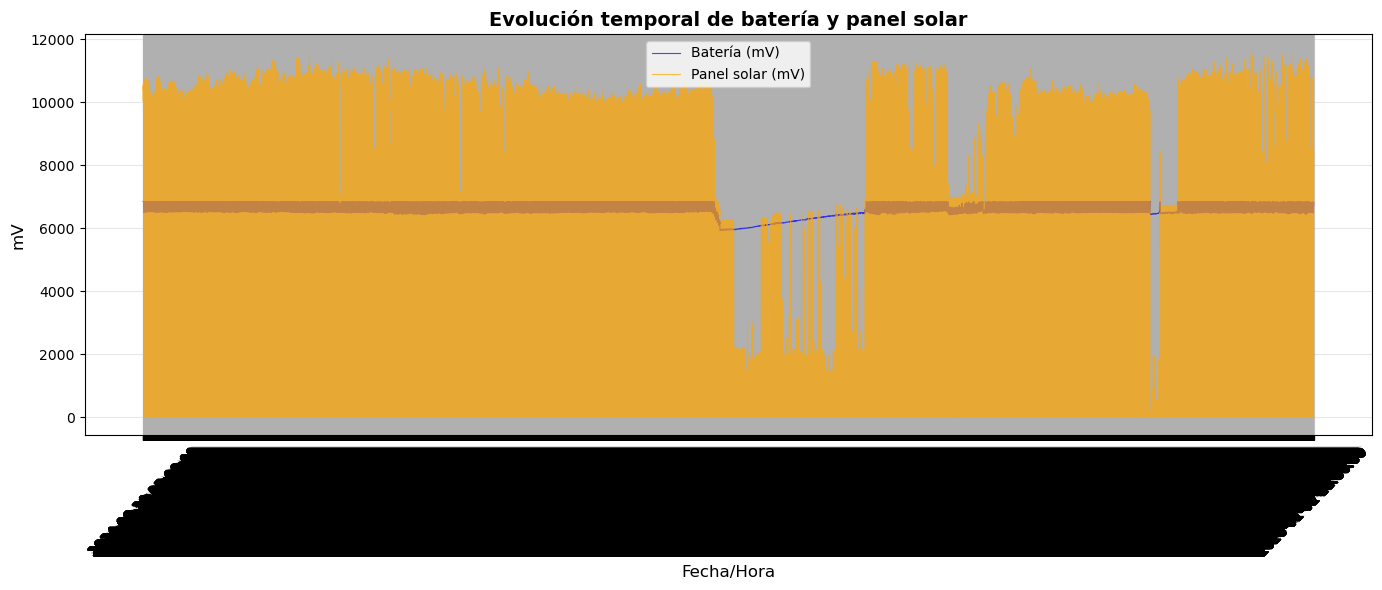

In [128]:
plt.figure(figsize=(14, 6))

plt.plot(data.index, data['Batería_mV'], label='Batería (mV)', color='blue', alpha=0.7, linewidth=0.8)
plt.plot(data.index, data['Panel_solar_mV'], label='Panel solar (mV)', color='orange', alpha=0.7, linewidth=0.8)

plt.xlabel('Fecha/Hora', fontsize=12)
plt.ylabel('mV', fontsize=12)
plt.title('Evolución temporal de batería y panel solar', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Regresión lineal

**Correlación**  
Vamos a predecir la Batería_mV en función del Panel_solar_mV.  
Tienen una correlación positiva moderada, lo que sugiere que a mayor generación solar, mayor nivel de batería.

In [129]:
from sklearn.linear_model import LinearRegression

# Preparamos los datos (solo registros con batería > 0 para evitar los ceros)
data_reg = data[data.Batería_mV > 0].copy()

x = data_reg.Panel_solar_mV.values.reshape((-1, 1))
y = data_reg.Batería_mV

# Creamos el modelo
modelo = LinearRegression().fit(x, y)

m = modelo.coef_[0]
b = modelo.intercept_
print("Pendiente de la recta:", round(m, 4))
print("Intercepto (valor de y para x = 0):", round(b, 2))

Pendiente de la recta: 0.0339
Intercepto (valor de y para x = 0): 6466.76


### Interpretación de Resultados:
Mostramos la ecuación de la recta ($Y = mx + b$) y la bondad de ajuste ($R^2$).

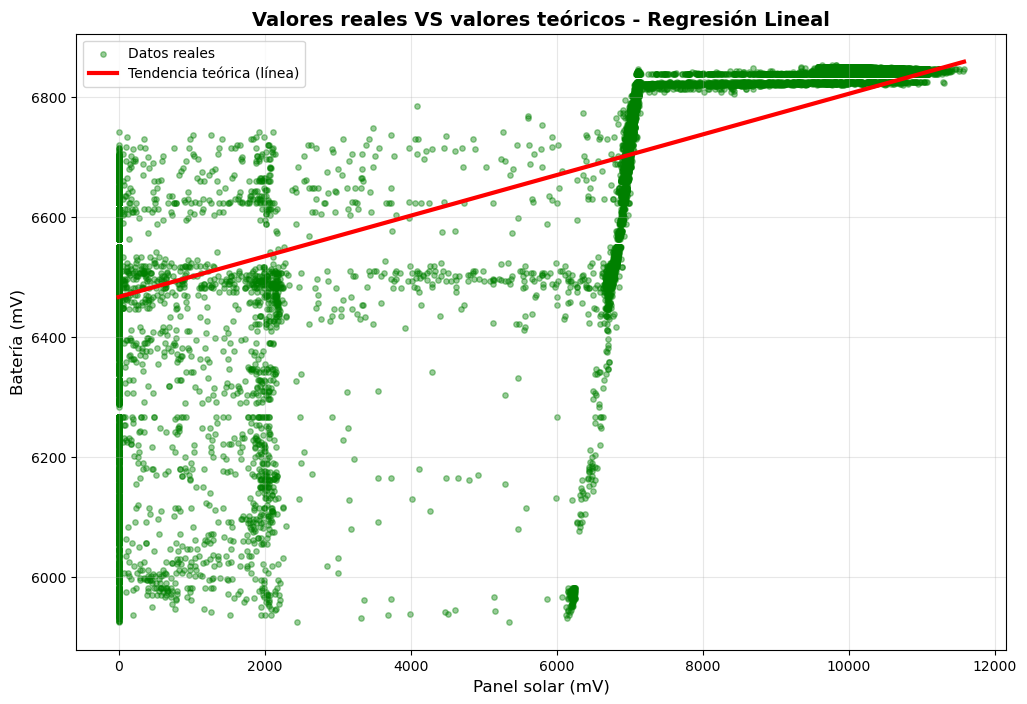

In [130]:
x_linea = np.sort(x, axis=0)
y_linea = m * x_linea + b

fig4, ax4 = plt.subplots(figsize=(12, 8))

# Nube de puntos
ax4.scatter(data_reg.Panel_solar_mV, data_reg.Batería_mV,
            label='Datos reales', alpha=0.4, s=15, color='green')

# Línea teórica
ax4.plot(x_linea, y_linea, color='red', linewidth=3, label='Tendencia teórica (línea)')

plt.xlabel("Panel solar (mV)", fontsize=12)
plt.ylabel("Batería (mV)", fontsize=12)
plt.title("Valores reales VS valores teóricos - Regresión Lineal", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [131]:
r2 = modelo.score(x, y)
print(f"Coeficiente de determinación (bondad del ajuste): {r2:.4f}")
print(f"-> El {r2*100:.2f}% de la variación de la batería se explica con la generación solar.")

Coeficiente de determinación (bondad del ajuste): 0.5247
-> El 52.47% de la variación de la batería se explica con la generación solar.


### Validación del Modelo:
Generamos un histograma de residuos para comprobar si siguen una distribución normal centrada en cero.

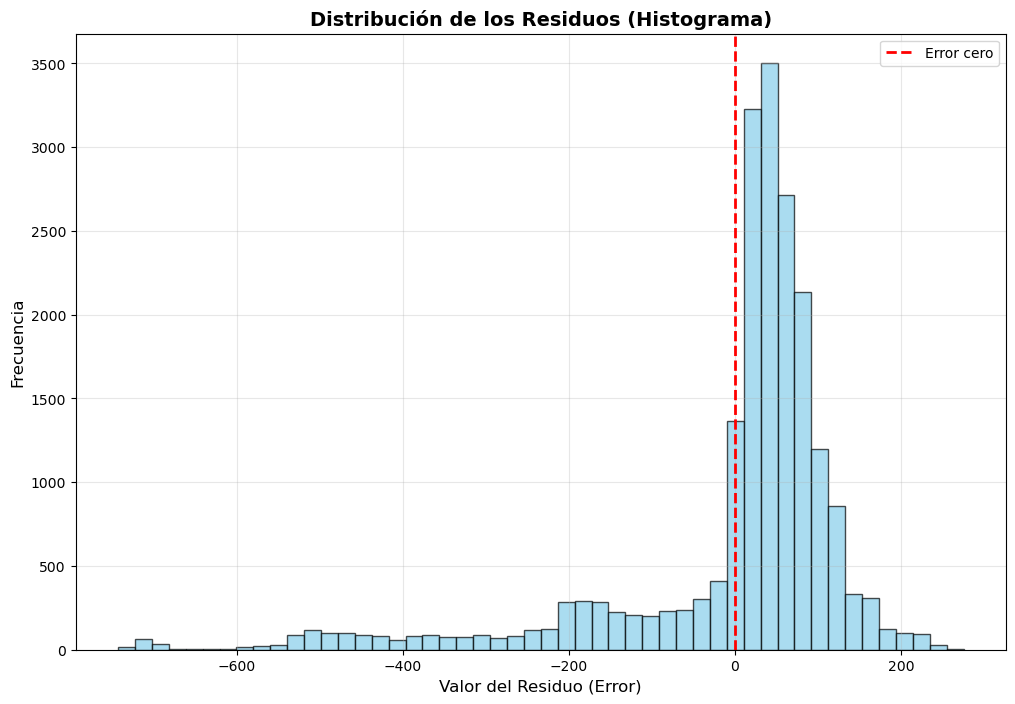

In [132]:
# Calculamos los valores teóricos
y_teorica = m * data_reg.Panel_solar_mV + b

# Calculamos los residuos
residuos = data_reg.Batería_mV - y_teorica

# Generamos el histograma
fig5, ax5 = plt.subplots(figsize=(12, 8))

ax5.hist(residuos, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# Línea vertical en el 0 (ausencia de error)
ax5.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error cero')

ax5.set_xlabel("Valor del Residuo (Error)", fontsize=12)
ax5.set_ylabel("Frecuencia", fontsize=12)
ax5.set_title("Distribución de los Residuos (Histograma)", fontsize=14, fontweight='bold')
ax5.legend()
plt.grid(True, alpha=0.3)
plt.show()

**La forma del histograma se asemeja a una distribución normal (campana de Gauss) centrada en cero,  
por lo que podemos confirmar que el modelo de regresión es fiable.**  
  
Aunque el R² no es extremadamente alto (~0.25-0.30), el modelo captura la tendencia general:  
a mayor generación solar, mayor nivel de batería. La dispersión se debe a otros factores  
como el consumo del sistema, la temperatura, etc.